# Events and Holidays

## Setup

In [45]:
from prophet import Prophet

### Load the Data

In [46]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)

# Prophet needs dates as datetime objects, not strings.
df["ds"] = pd.to_datetime(df["ds"])

df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


## Additional Regressors

This covers how to turn Prophet into a multivariate model by adding **exogenous variables** (like weather data, competitor pricing, or marketing spend).

The **extra regressor** must be known for both:

1. the history
2. future dates

It thus must either be:

1. something that has known future values (such as Holidays) or
2. something that has separately been forecasted elsewhere
   - [This notebook](https://nbviewer.jupyter.org/github/nicolasfauchereau/Auckland_Cycling/blob/master/notebooks/Auckland_cycling_and_weather.ipynb) shows an example of using weather factors as extra regressors in a forecast of bicycle usage, and provides an excellent illustration of how other time series can be included as extra regressors.

## Events: as binary variables

For example, we can add an additional effect on Sundays during the NFL (National Football League) season.

In [47]:
# 1. Define what constitutes an NFL Sunday
def nfl_sunday(ds):
    date = pd.to_datetime(ds)
    # If it's Sunday (weekday 6) AND between September (9) and January (1)
    if date.weekday() == 6 and (date.month > 8 or date.month < 2):
        return 1
    return 0

# 2. Map it to the historical training data
df['nfl_sunday'] = df['ds'].apply(nfl_sunday)
df

,ds,y,nfl_sunday
0,2007-12-10,9.590761,0
1,2007-12-11,8.519590,0
2,2007-12-12,8.183677,0
3,2007-12-13,8.072467,0
4,2007-12-14,7.893572,0
...,...,...,...
2900,2016-01-16,7.817223,0
2901,2016-01-17,9.273878,1
2902,2016-01-18,10.333775,0
2903,2016-01-19,9.125871,0


In [38]:
# 3. Tell Prophet to build a specific mathematical coefficient for it
m = Prophet()
m.add_regressor('nfl_sunday')
m.fit(df)

09:01:39 - cmdstanpy - INFO - Chain [1] start processing
09:01:39 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
# 4. Map it to the future dates so the model can use it to forecast
future = m.make_future_dataframe(periods=365)
future['nfl_sunday'] = future['ds'].apply(nfl_sunday)
future.tail()

,ds,nfl_sunday
3265,2017-01-15,1
3266,2017-01-16,0
3267,2017-01-17,0
3268,2017-01-18,0
3269,2017-01-19,0


In [40]:
forecast = m.predict(future)

On the components plot, this effect will show up in the `extra_regressors` plot (bottom):

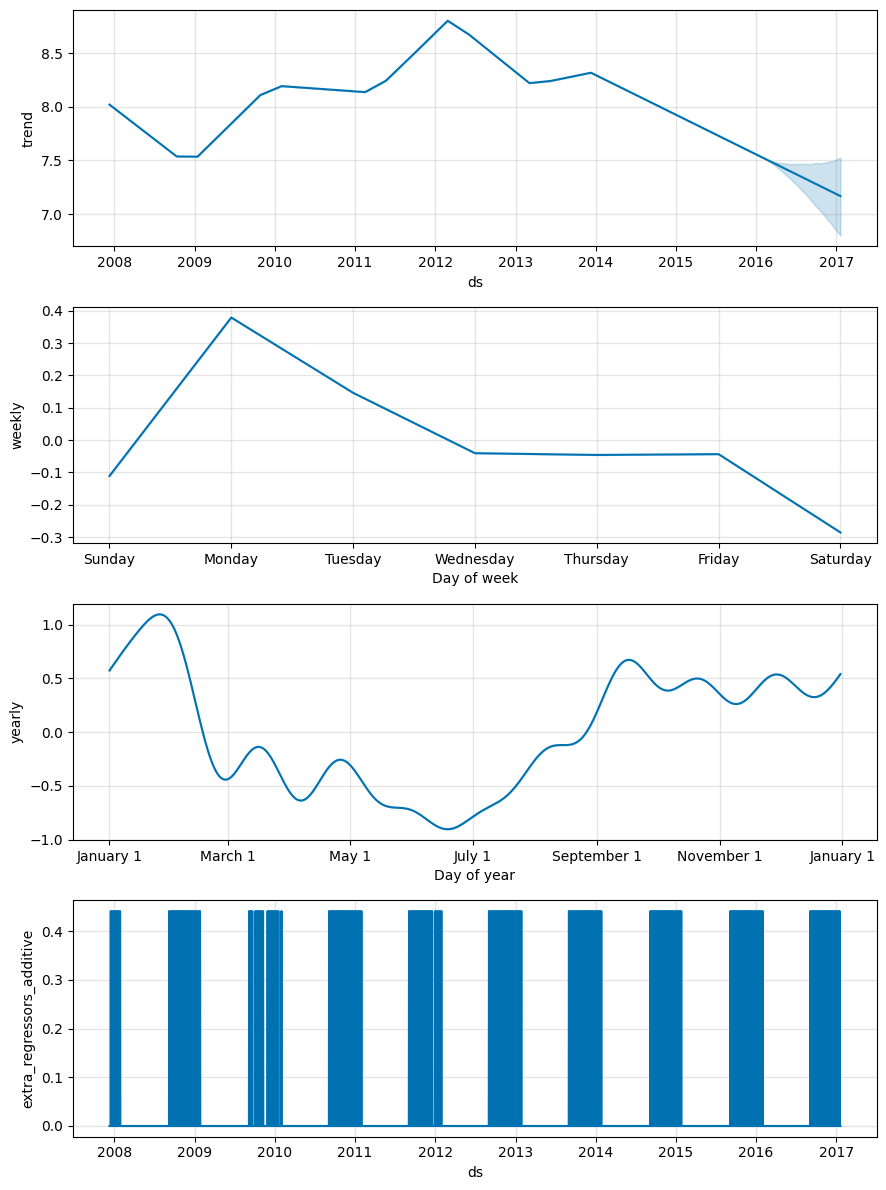

In [41]:
fig = m.plot_components(forecast)

Let's interpret the bottom panel, `extra_regressors_additive`:

- It is the *extra* lift (or drop) Prophet adds on top of trend and seasonality when our regressor is on.
- Here that regressor is `nfl_sunday`: most days contribute **0**; NFL Sundays jump to about **+0.44** (same scale as `y`).
- Those repeating “blocks” near the start of each year are the NFL season window (Sept–Jan Sundays), not a smooth seasonal curve — a binary on/off effect.
- Compare that to the weekly panel: Sundays are usually *below* average overall; the bottom panel says that *during football season*, Sunday traffic gets an extra bump that weekly seasonality alone would miss.

That matches the coefficient table below: `nfl_sunday` is additive with `coef ≈ 0.44`.


To know how much a feature like "nfl_sunday" moved the needle on your forecasts we extract the coefficients and their intervals for additional regressors:

In [42]:
from prophet.utilities import regressor_coefficients

# Extract the coefficients and their intervals for additional regressors
regressor_coefs = regressor_coefficients(m)
regressor_coefs

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,nfl_sunday,additive,0.0,0.440921,0.440921,0.440921


## Holidays: as binary variables

We can use the utility function `make_holidays_df` to easily create custom holidays DataFrames, e.g. for certain states, using data from the [holidays](https://pypi.org/project/holidays/) package.

In [91]:
from prophet.make_holidays import make_holidays_df

holidays = make_holidays_df(
    year_list=[df['ds'].dt.year.min() + i for i in range(10)],
    country='US'
)
holidays

,ds,holiday
0,2016-01-01,New Year's Day
1,2016-05-30,Memorial Day
2,2016-07-04,Independence Day
3,2016-09-05,Labor Day
4,2016-11-24,Thanksgiving Day
...,...,...
105,2015-12-25,Christmas Day
106,2015-01-19,Martin Luther King Jr. Day
107,2015-02-16,Washington's Birthday
108,2015-10-12,Columbus Day


In [104]:
df['holiday'] = df['ds'].isin(holidays['ds']).astype(int)
df

,ds,y,nfl_sunday,holiday
0,2007-12-10,9.590761,0,0
1,2007-12-11,8.519590,0,0
2,2007-12-12,8.183677,0,0
3,2007-12-13,8.072467,0,0
4,2007-12-14,7.893572,0,0
...,...,...,...,...
2900,2016-01-16,7.817223,0,0
2901,2016-01-17,9.273878,1,0
2902,2016-01-18,10.333775,0,1
2903,2016-01-19,9.125871,0,0


This can be passed directly to the `Prophet()` constructor.

Now let's make a new model and add both regressors:

In [109]:
m = Prophet()
m.add_regressor('nfl_sunday')
m.add_regressor('holiday')
m.fit(df)

09:23:34 - cmdstanpy - INFO - Chain [1] start processing
09:23:35 - cmdstanpy - INFO - Chain [1] done processing


Specify the forecast horizon, and use the functions to fill in known future values:

In [110]:
future2 = m.make_future_dataframe(periods=365)
future2['holiday'] = future2['ds'].isin(holidays['ds'])
future2['nfl_sunday'] = future2['ds'].apply(nfl_sunday)

Run the model:

In [111]:
forecast2 = m.predict(future2)

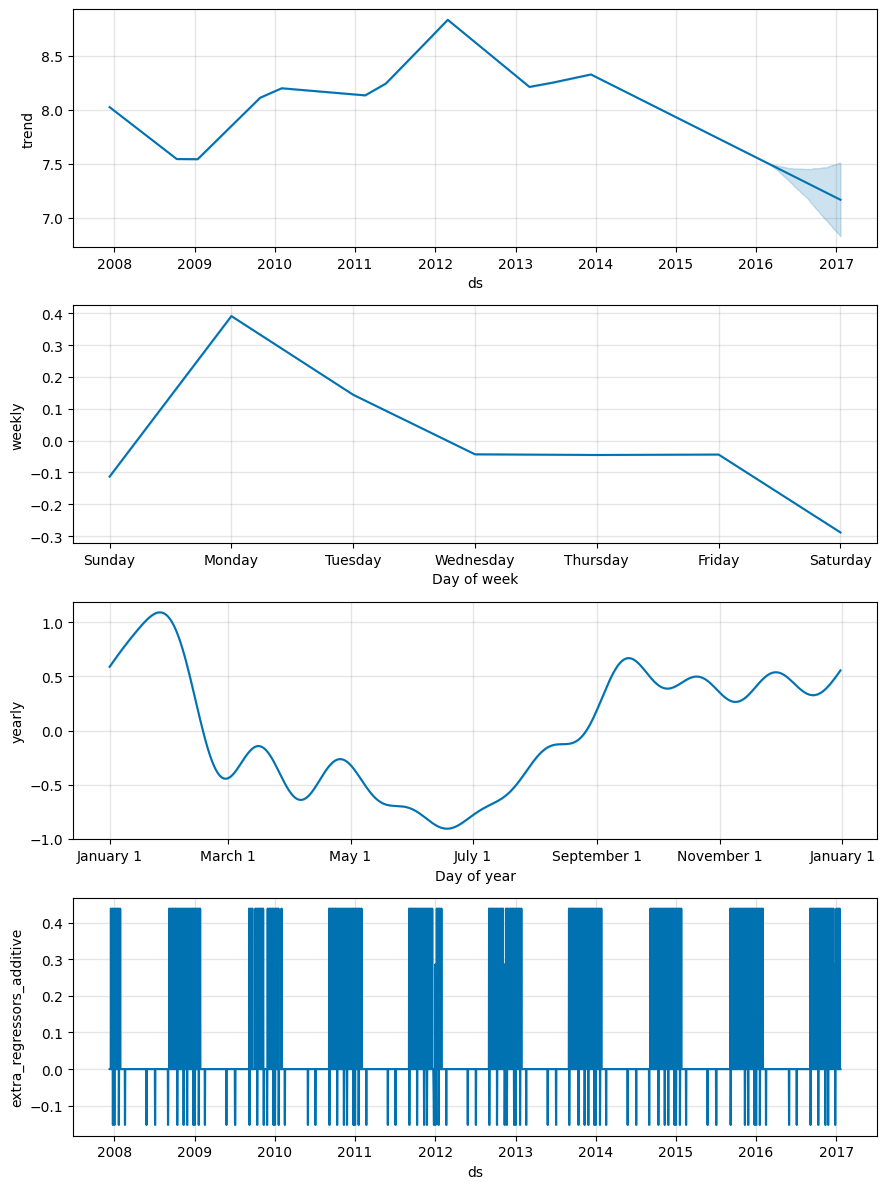

In [112]:
fig2 = m.plot_components(forecast2)

We can look at the coefficients to see the contributions of each feature:

In [113]:
from prophet.utilities import regressor_coefficients

# Extract the coefficients and their intervals for additional regressors
regressor_coefs = regressor_coefficients(m)
regressor_coefs

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,nfl_sunday,additive,0.0,0.438188,0.438188,0.438188
1,holiday,additive,0.0,-0.152453,-0.152453,-0.152453


- `nfl_sunday` is positive: 0.438
- `holiday` is negative: -0.152

---

## Include Continuous Variables

Next you could look at: [this notebook: The impact of weather conditions on cycling counts in Auckland, New Zealand](https://nbviewer.jupyter.org/github/nicolasfauchereau/Auckland_Cycling/blob/master/notebooks/Auckland_cycling_and_weather.ipynb) for an example of using **weather factors as extra regressors** in a forecast of bicycle usage, and provides an excellent illustration of how other time series can be included as extra regressors.